## ddHodge workflow: FUCCI

## Setup

In [1]:
using GLMakie, JLD2, FreqTables, DataFrames, LinearAlgebra
using StatsBase: mean, median, cor, quantile

# To write the results back to h5ad (if required)
@isdefined(H5Adh) || include("../tools/H5ADHelper.jl")

# clipping for visualization
function clip(x,p=[0.01,0.99])
    position(p) = Int.(round.(length(x)*p))
    p = length(p)==1 ? [p,1-p] : p
    lower, upper = position.(p)
    xs = sort(x)
    clamp.(x,xs[lower],xs[upper])
end

clipmax(x;p=0.05) = maximum(abs.(clip(x,p)))

clipmax (generic function with 1 method)

In [2]:
forPrint = false # white background and SVG
if forPrint
    # for figure
    import CairoMakie
    CairoMakie.activate!(type="svg")
    set_theme!( 
        theme_minimal(),fontsize=14,fonts=(;regular="Helvetica"),
        Axis=(xticksvisible=true,yticksvisible=true,)
    )
else
    # for daily use
    GLMakie.activate!(px_per_unit=1)
    set_theme!(
        theme_black(),
        backgroundcolor=RGBf([40,42,54]/255...),
        Colorbar = (spinewidth=0,),
        Legend = (backgroundcolor=:transparent,framevisible=false)
    )
end
#Makie.theme(:fonts)

## Load data

select files and visualization methods (PCA/t-SNE/UMAP), then go

In [3]:
#h5file = "../data/embryo_1-34ss.h5ad"
h5file = "../data/scvelo_fucci.h5ad"

import Muon
adata = Muon.readh5ad(h5file,backed=false)
viz = "umap"
names(adata.obs)

16-element Vector{String}:
 "n_genes_by_counts"
 "total_counts"
 "S_score"
 "G2M_score"
 "phase"
 "initial_size_unspliced"
 "initial_size_spliced"
 "initial_size"
 "n_counts"
 "velocity_self_transition"
 "leiden"
 "clusters"
 "prefixu"
 "prefixdiv"
 "prefixrot"
 "prefixvgrass"

In [4]:
npc = 40
X = adata.obsm["X_pca"][:,1:npc]'
V = adata.obsm["velocity_pca"][:,1:npc]'
loadings = adata.varm["PCs"][:,1:npc]
# for visualization
X_viz = adata.obsm["X_$viz"]'
V_viz = adata.obsm["velocity_$viz"]'
pts = Point2f.(eachcol(X_viz))
N = size(X,2)

1152

## Clusters

### Set main annotation and colors

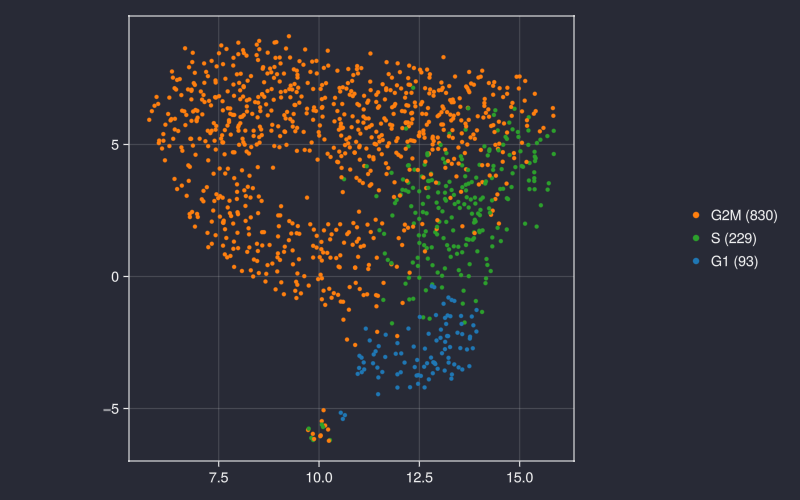

In [5]:
# Main annotation name to show
#anno = :major_trajectory
#anno = :majority_voting
#anno = :celltype
anno = :phase
#anno = :clusters
#anno = :Age
ms = 6 # global marker size

cats = string.(adata.obs[!,anno])
lvs = levels(cats)
lvfreq = sort(freqtable(cats),rev=true)
#cname = :tab10 #:glasbey_hv_n256 #:glasbey_bw_minc_20_maxl_70_n256
#cname = :glasbey_bw_minc_20_minl_30_n256 # nice for darktheme
cname = :tab10
cpal = Dict(zip(lvs,resample_cmap(cname,max(length(lvs),10))))
let
    lvs = names(lvfreq[1:min(15,length(levels(cats)))])[1] # show top 10 freq.
    lvs = lvs[lvfreq[lvs] .>= 2] # at least 2 cells
    labels = [string(lv)*" ($(lvfreq[lv]))" for lv in lvs]
    fig = Figure(size=(800,500))
    ax = Axis(fig[1,1],aspect=1)
    scatter!(ax, pts, markersize=ms, color=[cpal[c] for c in cats],rasterize=2)
    Legend(fig[1,2],[MarkerElement(marker=:circle, color=cpal[p]) for p in lvs],labels,nbanks=1)
    fig
end

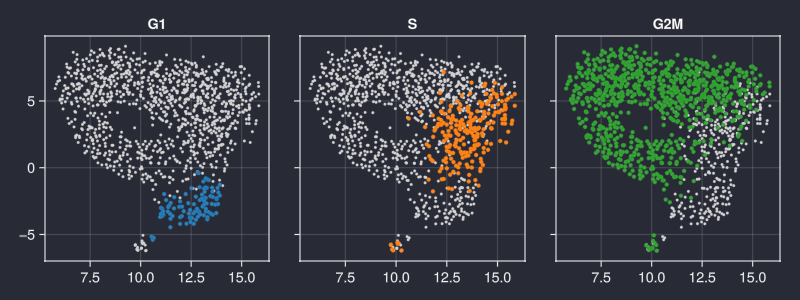

In [6]:
let ms = ms
    cats = adata.obs.phase
    lvs = ["G1","S","G2M"]
    ppal = Dict(zip(lvs,resample_cmap(:tab10,10)))
    pcols = [get(ppal,c,:lightgrey) for c in cats]
    fig = Figure(size=(800,300),)
    axs = [Axis(fig[1,i],aspect=1,title=lvs[i]) for i in 1:length(lvs)]
    for i in 1:3
        scatter!(axs[i],pts,markersize=4,color=:lightgrey)
        pshow = cats .== lvs[i]
        scatter!(axs[i],pts[pshow],markersize=ms,color=(ppal[lvs[i]],0.9))
    end
    [axs[i].yticklabelsvisible = false for i in 2:3]
    linkaxes!(axs...)
    fig
end

## Workflow

In [7]:
struct Params
    k::Int
    d::Int
    λ::AbstractFloat
    ϵ::AbstractFloat
end

par = Params(12,4,0.1,1.0)

Params(12, 4, 0.1, 1.0)

### Graph construction

In [8]:
using ddHodge
@time g, kdtree = kNNGraph(X,par.k) # slow for higher dimension

  0.921938 seconds (2.53 M allocations: 122.655 MiB, 98.41% compilation time)


(Graphs.SimpleGraphs.SimpleGraph{Int64}(10926, [[200, 230, 244, 371, 379, 385, 432, 591, 594, 642, 884, 918, 1023, 1132, 1148], [87, 127, 143, 147, 241, 319, 593, 810, 917, 1012, 1042, 1050, 1077, 1092], [169, 207, 216, 379, 406, 595, 608, 772, 869, 935, 999, 1023], [10, 57, 67, 69, 83, 109, 228, 240, 254, 277  …  833, 882, 888, 923, 958, 963, 999, 1040, 1136, 1149], [28, 50, 146, 159, 295, 388, 429, 501, 558, 575, 602, 673, 766, 836, 1022, 1142, 1151], [29, 171, 193, 250, 263, 291, 348, 436, 497, 536  …  699, 815, 825, 871, 880, 1030, 1031, 1073, 1110, 1114], [162, 207, 244, 390, 534, 575, 653, 754, 807, 932, 997, 1022, 1074, 1128, 1151], [9, 80, 104, 164, 187, 191, 204, 216, 288, 311  …  735, 737, 793, 853, 983, 1001, 1007, 1008, 1047, 1120], [8, 204, 343, 346, 356, 389, 725, 735, 793, 826, 853, 880, 961, 983, 1010], [4, 68, 69, 185, 377, 439, 504, 521, 557, 595, 649, 685, 821, 882, 935, 938, 987, 1078, 1145]  …  [11, 17, 71, 275, 332, 375, 376, 380, 381, 408, 451, 467, 664, 731, 759

In [9]:
#import CUDA
resume = false
jldfile = join(["../data/",split(basename(h5file),'.')[1],"_pca_k$(par.k)_d$(par.d).jld2"])
@show jldfile
ddh = if resume & isfile(jldfile)
    @time load(jldfile)["ddh"]
else
    #CUDA.@time ddh = ddHodgeWorkflow(g,X,V,rdim=par.d,λ=par.λ,ϵ=par.ϵ,ssa=true,ssart=2,krytol=1e-32,useCUDA=true);
    ddh = ddHodgeWorkflow(g,X,V,rdim=par.d,λ=par.λ,ϵ=par.ϵ,ssa=true,ssart=2,krytol=1e-32,useCUDA=false);
    save(jldfile,"ddh",ddh)
    ddh
end

jldfile = "../data/scvelo_fucci_pca_k12_d4.jld2"


[ Info: (1/4) Potential estimation
[ Info: ... done in 0.331 sec.
[ Info: (2/4) Tangent space estimation
[ Info: Consistency of orientations: 0.5614131429617426
[ Info: ... done in 1.07 sec.
[ Info: (3/4) Hessian matrix estimation
[ Info: ... done in 2.912 sec.
[ Info: (4/4) Jacobian matrix estimation
[ Info: Consistency of orientations (plane): 0.5642504118616145
[ Info: ... done in 4.738 sec.


:::ddHodgge::: values over graph {1152, 10926}, dimensions: 40 -> 4 (ssa: on)

## Check results

n2s[2:3] / n2s[1] = [0.5107688821637469, 0.4892311178350525]


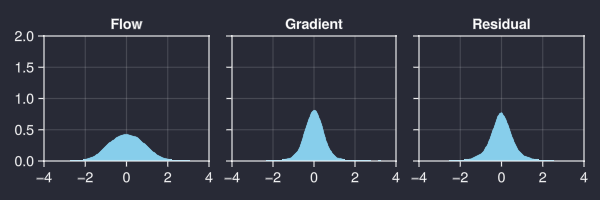

In [10]:
let
    fig = Figure(size=(600,200))
    titles = ["Flow", "Gradient", "Residual"]
    values = [ddh.w, -ddh.d0*ddh.u, ddh.w+ddh.d0*ddh.u]/sqrt(mean(abs2.(ddh.w)))
    n2s = norm.(values).^2
    @show (n2s[2:3]/n2s[1])
    axs = [Axis(fig[1,i],title=titles[i]) for i in 1:3]
    #[hist!(axs[i], values[i], bins=200, color=:skyblue,normalization=:pdf,rasterize=2) for i in 1:3]
    [density!(axs[i], values[i], rasterize=2, color=:skyblue) for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in 2:3]
    xlims!.(axs,-4,4)
    ylims!.(axs,0,2)
    linkaxes!(axs...)
    fig
end

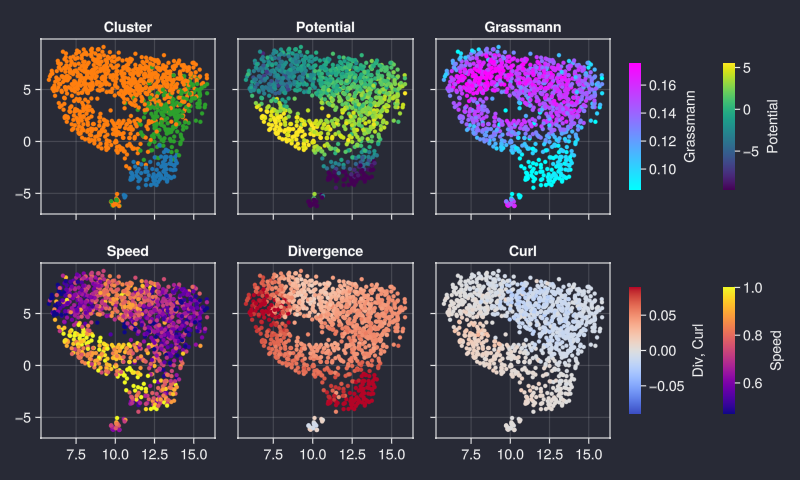

In [11]:
fig = let ms = ms, clp = 0.05
    speeds = norm.(eachcol(V))
    #fig = Figure(size=(1000,600))
    fig = Figure(size=(800,480))
    #titles = ["Cluster w/ stream", "Potential", "Grassmann", "Speed", "Divergence", "Curl"]
    titles = ["Cluster", "Potential", "Grassmann", "Speed", "Divergence", "Curl"]
    axs = [Axis(fig[divrem(i-1,3).+1...],title=titles[i],aspect=1) for i in 1:length(titles)]
    scatter!(axs[1], pts, markersize=ms, color=[cpal[c] for c in cats],rasterize=2)
    #stream!(axs[1],gridsize=(40,40),arrow_size=8)
    pltu = scatter!(axs[2], pts, color=clip(ddh.u,clp), colormap=:viridis, markersize=ms,rasterize=2)
    pltg = scatter!(axs[3],pts,color=clip(ddh.vgrass,clp),markersize=ms,colormap=:cool,rasterize=2)
    plts = scatter!(axs[4],pts, color=clip(speeds,clp), colormap=:plasma,markersize=ms,rasterize=2)
    vmax = clipmax([ddh.div;ddh.rot],p=clp)
    pltd = scatter!(axs[5], pts, color=ddh.div, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax),rasterize=2)
    scatter!(axs[6], pts, color=ddh.rot, colormap=:coolwarm, markersize=ms, colorrange=(-vmax,vmax),rasterize=2)
    Colorbar(fig[1,4],pltg,label="Grassmann",height=Relative(0.7))
    Colorbar(fig[1,5],pltu,height=Relative(0.7),label="Potential")
    Colorbar(fig[2,4],pltd,height=Relative(0.7),label="Div, Curl")
    Colorbar(fig[2,5],plts,height=Relative(0.7),label="Speed",vertical=true)
    [axs[i].xticklabelsvisible = false for i in 1:3]
    [axs[i].yticklabelsvisible = false for i in [2,3,5,6]]
    linkaxes!(axs...)
    fig
end

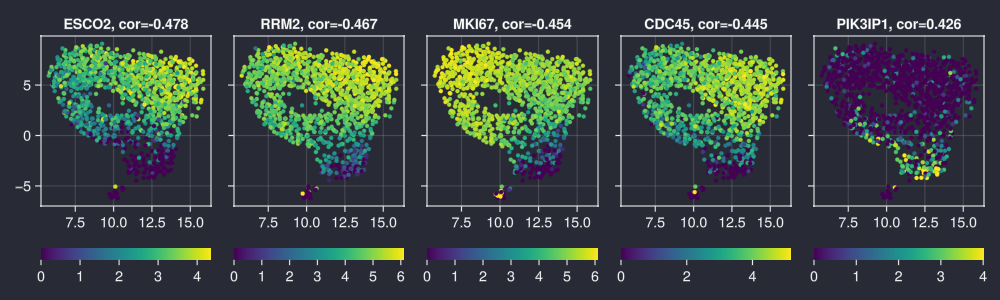

In [12]:
let vals=ddh.div, thr=0.01, ms=ms, cmap=:viridis
    cc = vec(cor(adata.X,vals))
    idx = sortperm(abs.(cc);rev=true)[1:5]
    genes = adata.var_names[idx]
    corrs = round.(cc[idx],digits=3)
    n = length(genes)
    idxs = indexin(genes,adata.var_names)
    fig = Figure(size=(1000,300))
    axs = [Axis(fig[1,i],title="$(genes[i]), cor=$(corrs[i])",aspect=1) for i in 1:n]
    for i in 1:n
        expr = collect(adata.X[:,idxs[i]])
        plt=scatter!(axs[i],pts,color=clip(expr,thr),markersize=ms,colormap=cmap,rasterize=2)
        Colorbar(fig[2,i],plt,vertical=false,flipaxis=false)
    end
    [axs[i].yticklabelsvisible=false for i in 2:n]
    linkaxes!(axs...)
    fig
end

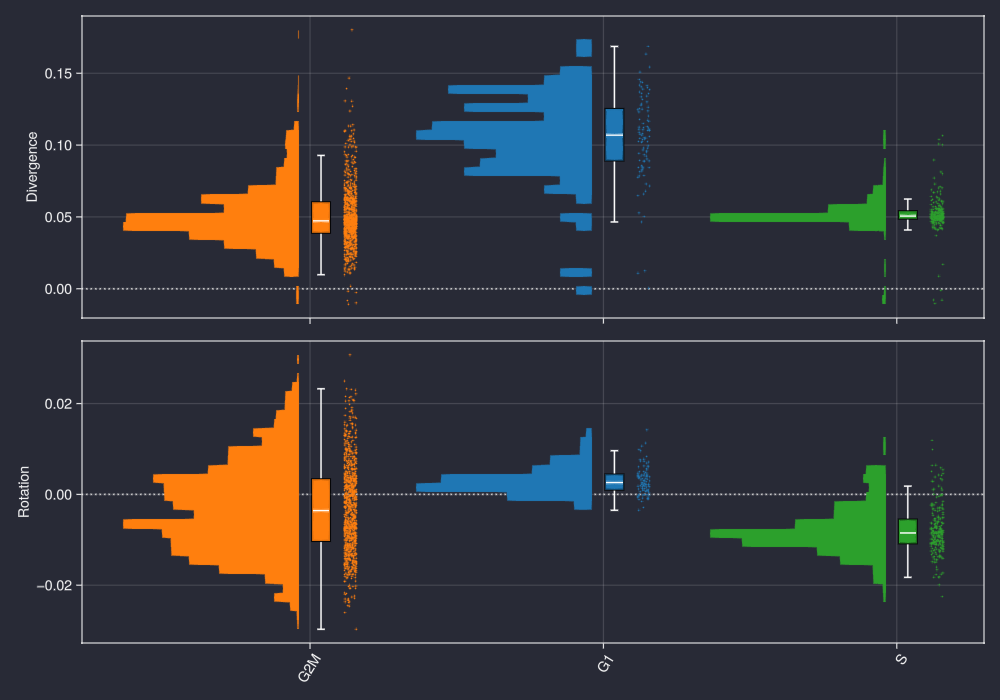

In [13]:
let
    fig = Figure(size=(1000,700))
    ax1 = Axis(fig[1,1],xticklabelrotation=45.0,ylabel="Divergence")
    ax2 = Axis(fig[2,1],xticklabelrotation=45.0,ylabel="Rotation")
    hlines!(ax1, [0], color=:lightgrey, linestyle=:dot)
    rainclouds!(ax1, string.(cats), ddh.div, color=[cpal[c] for c in cats],clouds=hist,rasterize=2)
    hlines!(ax2, [0], color=:lightgrey, linestyle=:dot)
    rainclouds!(ax2, string.(cats), ddh.rot, color=[cpal[c] for c in cats],clouds=hist,rasterize=2)
    ax1.xticklabelsvisible=false
    ax1.xticks=1:length(unique(cats))
    ax2.xticks=(1:length(unique(cats)),unique(string.(cats)))
    linkxaxes!(ax1,ax2)
    fig
end

## Canalization plots
Visualization of cell state stability in embryonic devlopment

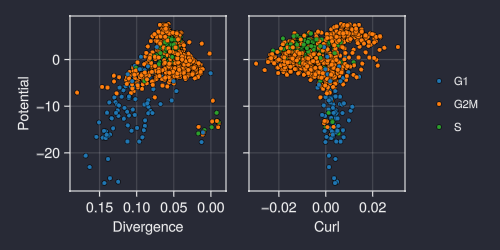

In [14]:
let
    fig = Figure(size=(500,250))
    ax1 = Axis(fig[1,1],xlabel="Divergence",ylabel="Potential",xreversed=true)
    ax2 = Axis(fig[1,2],xlabel="Curl",yticklabelsvisible=false)
    [
        scatter!(
            ax,val,ddh.u,markersize=ms, rasterize=2,
            color=[cpal[c] for c in cats],strokewidth=0.5
        ) for (ax,val) = [(ax1,ddh.div),(ax2,ddh.rot)]
    ]
    Legend(fig[1,3],[MarkerElement(marker=:circle,markersize=ms,strokewidth=0.5,color=cpal[p]) for p in lvs],lvs,labelsize=11)
    fig
    #scatter(axs[2],ddh.rot,ddh.u,markersize=6,color=[cpal[c] for c in cats],strokewidth=0.5)
end

## Write back to h5ad

In [15]:
### Reflect the results to loaded anndata
let 
    featurestowrite = [:u,:div,:rot,:vgrass]
    [adata.obs[!,"ddh_$(ft)"] = getfield(ddh,ft) for ft in featurestowrite]
    H5Adh.insertddh(h5file,ddh,keys=featurestowrite) # save if needed
end

## Cycles

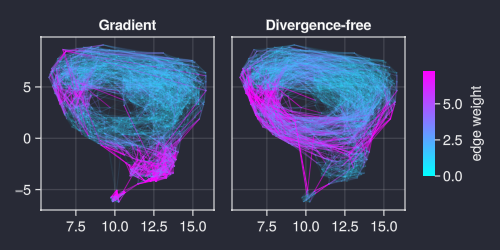

In [16]:
using GraphMakie
let cmap = :cool
    titles = ["Gradient","Divergence-free"]
    gr = [-ddh.d0*ddh.u ddh.w+ddh.d0*ddh.u]
    wmax = quantile(vec(gr),0.99)
    fig = Figure(size=(500,250))
    axs = [Axis(fig[1,i],aspect=1,title=titles[i]) for i in axes(gr,2)]
    for i in axes(gr,2)
        w = gr[:,i]
        graphplot!(
            axs[i], g, layout=pts, node_size=0,
            edge_color=abs.(w), edge_width=0.05abs.(w),
            edge_attr=(;colormap=cmap,colorrange=(0,wmax)),
            transparency=true, rasterize=2,
        )
    end
    Colorbar(
        fig[1,3],colormap=cmap,colorrange=(0,wmax),
        height=Relative(0.6),label="edge weight"
    )
    hideydecorations!.(axs[2], grid = false)
    linkaxes!(axs...)
    fig
end